In [1071]:
# import sys
# !{sys.executable} -m pip install lifelines

In [1072]:
from pycox.models import CoxPH
from pycox.utils import kaplan_meier
from torchtuples import optim
from sklearn_pandas import DataFrameMapper
from sklearn.preprocessing import StandardScaler
from lifelines.statistics import logrank_test
from pycox.datasets import gbsg

import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torchtuples as tt
import numpy as np
import pandas as pd

In [1073]:
# np.random.seed(234)
# _ = torch.manual_seed(123)

In [1074]:
# data_file_path = 'data/gbsg.csv'
# df = pd.read_csv(data_file_path)
df = gbsg.read_df()

In [1075]:
df.describe()

,x0,x1,x2,x3,x4,x5,x6,duration,event
count,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000
mean,0.262097,0.836021,0.588710,55.077061,5.163530,142.014786,143.925186,44.491585,0.567652
std,0.439874,0.647716,0.492178,12.258657,5.075552,274.075226,240.159775,27.629768,0.495513
min,0.000000,0.000000,0.000000,21.000000,1.000000,0.000000,0.000000,0.262834,0.000000
25%,0.000000,0.000000,0.000000,46.000000,2.000000,6.000000,10.000000,19.121149,0.000000
50%,0.000000,1.000000,1.000000,55.000000,3.000000,37.000000,54.000000,40.229979,1.000000
75%,1.000000,1.000000,1.000000,64.000000,7.000000,161.250000,173.000000,71.104721,1.000000
max,1.000000,2.000000,1.000000,90.000000,51.000000,5004.000000,3008.000000,87.359344,1.000000


In [1076]:
for col in df:
    print(col)
    print(df[col].nunique())

x0
2
x1
3
x2
2
x3
68
x4
33
x5
513
x6
513
duration
1230
event
2


In [1077]:
df_test = df.sample(frac=0.2)
df_train = df.drop(df_test.index)
df_val = df_train.sample(frac=0.2)
df_train = df_train.drop(df_val.index)

## Data Processing

In [1078]:
for col in df:
    print(col)
    print(df[col].nunique())

x0
2
x1
3
x2
2
x3
68
x4
33
x5
513
x6
513
duration
1230
event
2


In [1079]:
print(df.columns)

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'duration', 'event'], dtype='object')


In [1080]:
covariates_cols = [
    "age",
    "meno",
    "size",
    "grade",
    "nodes",
    "pgr",
    "er",
    "hormon",
]

In [1081]:
cols_standardize = ['x1', 'x3', 'x4', 'x5', 'x6']
cols_leave = ['x0', 'x2']

standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

print(standardize + leave)

x_mapper = DataFrameMapper(standardize + leave)

[(['x1'], StandardScaler()), (['x3'], StandardScaler()), (['x4'], StandardScaler()), (['x5'], StandardScaler()), (['x6'], StandardScaler()), ('x0', None), ('x2', None)]


In [1082]:
time_col = 'duration'
event_col = 'event'

In [1083]:
x_train = x_mapper.fit_transform(df_train).astype('float32')
x_val = x_mapper.transform(df_val).astype('float32')
x_test = x_mapper.transform(df_test).astype('float32')
x_all = x_mapper.transform(df).astype('float32')

In [1084]:
get_target = lambda df: (df[time_col].values, df[event_col].values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = x_val, y_val

times, events = get_target(df)

In [1085]:
x_train

array([[-1.3047423 , -1.925861  , -0.8143958 , ...,  0.11527664,
         0.        ,  0.        ],
       [ 0.24254131, -0.27173305, -0.8143958 , ...,  1.2656817 ,
         0.        ,  1.        ],
       [-1.3047423 , -2.2566864 , -0.8143958 , ..., -0.5561494 ,
         0.        ,  0.        ],
       ...,
       [ 0.24254131, -0.18902665,  2.3161263 , ..., -0.603192  ,
         1.        ,  1.        ],
       [ 0.24254131, -0.35443944, -0.03176527, ..., -0.603192  ,
         0.        ,  0.        ],
       [ 0.24254131, -0.27173305, -0.42308056, ..., -0.45778763,
         0.        ,  1.        ]], shape=(1429, 7), dtype=float32)

## Net

In [1086]:
in_features = x_train.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1
output_bias = False

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)

# net = nn.Sequential(
#     nn.Linear(len(covariates_cols), 32),
#     nn.ReLU(),
#     nn.Linear(32, 1)
# )

## Training

In [1087]:
model = CoxPH(net, tt.optim.Adam)

In [1088]:
model.optimizer.set_lr(0.01)

In [1089]:
epochs = 512
callbacks = [tt.callbacks.EarlyStopping()]
verbose = True
batch_size = 256

In [1090]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val, val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.9319,	val_loss: 4.5846
1:	[0s / 0s],		train_loss: 4.8152,	val_loss: 4.5847
2:	[0s / 0s],		train_loss: 4.7883,	val_loss: 4.5808
3:	[0s / 0s],		train_loss: 4.7841,	val_loss: 4.5971
4:	[0s / 0s],		train_loss: 4.7561,	val_loss: 4.5959
5:	[0s / 0s],		train_loss: 4.7521,	val_loss: 4.5886
6:	[0s / 0s],		train_loss: 4.7834,	val_loss: 4.5750
7:	[0s / 0s],		train_loss: 4.7683,	val_loss: 4.6135
8:	[0s / 0s],		train_loss: 4.7590,	val_loss: 4.5730
9:	[0s / 0s],		train_loss: 4.7519,	val_loss: 4.5683
10:	[0s / 0s],		train_loss: 4.7509,	val_loss: 4.5696
11:	[0s / 0s],		train_loss: 4.7472,	val_loss: 4.5682
12:	[0s / 0s],		train_loss: 4.7524,	val_loss: 4.5812
13:	[0s / 0s],		train_loss: 4.7401,	val_loss: 4.5866
14:	[0s / 0s],		train_loss: 4.7387,	val_loss: 4.5893
15:	[0s / 0s],		train_loss: 4.7236,	val_loss: 4.6062
16:	[0s / 0s],		train_loss: 4.7366,	val_loss: 4.5969
17:	[0s / 0s],		train_loss: 4.7309,	val_loss: 4.6040
18:	[0s / 0s],		train_loss: 4.7142,	val_loss: 4.5862
19:

In [1091]:
x_all[0]

array([-1.3047423 , -1.925861  , -0.8143958 ,  0.06096284,  0.11527664,
        0.        ,  0.        ], dtype=float32)

## Treatment Rec Evaluation

In [1092]:
treatment_col_index = -2 

recommendation_times = []
recommendation_events = []
anti_recommendation_times = []
anti_recommendation_events = []

for x, t, e in zip(x_all, times, events):
    risks = []
    real_treatment = x[treatment_col_index]
    
    x_without_treatment = np.copy(x)
    x_without_treatment[treatment_col_index] = 0
    risks.append(model.predict(x_without_treatment.reshape(1, -1)))

    x_with_treatment = np.copy(x)
    x_with_treatment[treatment_col_index] = 1
    risks.append(model.predict(x_with_treatment.reshape(1, -1)))

    predicted_treatment = np.argmin(risks)

    if real_treatment == predicted_treatment: 
        recommendation_times.append(t)
        recommendation_events.append(t)
    if real_treatment != predicted_treatment: 
        anti_recommendation_times.append(t)
        anti_recommendation_events.append(t)


In [1093]:
print(len(recommendation_times))
print(len(recommendation_events))
print(len(anti_recommendation_times))
print(len(anti_recommendation_events))

653
653
1579
1579


In [1094]:
km_rec = kaplan_meier(np.array(recommendation_times), np.array(recommendation_events))
km_anti = kaplan_meier(np.array(anti_recommendation_times), np.array(anti_recommendation_events))

/opt/homebrew/lib/python3.11/site-packages/pycox/utils.py:78: RuntimeWarning: invalid value encountered in log
  surv = np.exp(np.log(1 - di / ni).cumsum())


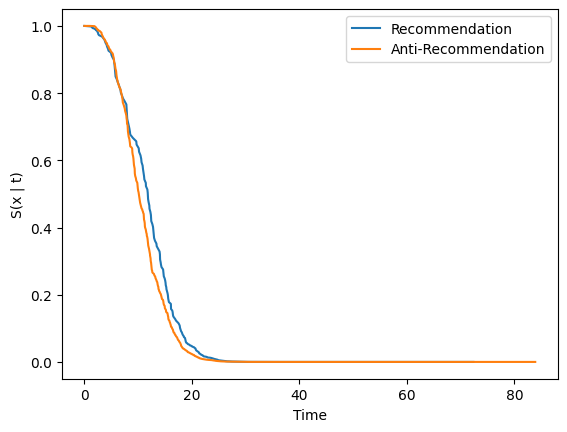

In [1095]:
km_rec.name = "Recommendation"
km_anti.name = "Anti-Recommendation"
plt.plot(km_rec, label=km_rec.name)
plt.plot(km_anti, label=km_anti.name)

plt.xlabel("Time")
plt.ylabel("S(x | t)")
plt.legend()
plt.show()

In [1096]:
result = logrank_test(recommendation_times, anti_recommendation_times, recommendation_events, anti_recommendation_events)

In [1097]:
print(result.p_value)

0.06061286875678445
